# F1 Pit Wall — EDA + FE
Race-level EDA for the finish-position prediction model.
Loads all 5 parquet sources, builds a driver × race frame, audits for leakage, and locks the final feature list.

In [48]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_ROOT      = Path().resolve().parent / 'data'
SESSION_FILTER = 'R'   # R = Race

## 1. Load data — race-level frame

`df` has **one row per driver per race** — the grain the model trains on.

Pipeline:
1. Read all 5 parquet types from every `session=R` partition
2. Aggregate weather and laps to session / driver-race level
3. Join into a single flat frame

In [49]:
SESSION_KEYS = ['year', 'round_number', 'session_type']
DRIVER_KEYS  = SESSION_KEYS + ['DriverNumber']

all_si, all_di, all_sr, all_laps, all_wx = [], [], [], [], []

for session_dir in DATA_ROOT.glob(f'**/session={SESSION_FILTER}'):
    all_si.append(pq.ParquetFile(session_dir / 'session_info.parquet').read().to_pandas())
    all_di.append(pq.ParquetFile(session_dir / 'driver_info.parquet').read().to_pandas())
    all_sr.append(pq.ParquetFile(session_dir / 'session_results.parquet').read().to_pandas())
    all_laps.append(pq.ParquetFile(session_dir / 'laps.parquet').read().to_pandas())
    all_wx.append(pq.ParquetFile(session_dir / 'weather.parquet').read().to_pandas())

session_info    = pd.concat(all_si,   ignore_index=True)
driver_info     = pd.concat(all_di,   ignore_index=True)
session_results = pd.concat(all_sr,   ignore_index=True)
laps_raw        = pd.concat(all_laps, ignore_index=True)
weather_raw     = pd.concat(all_wx,   ignore_index=True)

# ── Weather → session-level features ──────────────────────────────────────────
weather = (
    weather_raw
    .assign(Rainfall=lambda d: d['Rainfall'].astype(float))
    .groupby(SESSION_KEYS)
    .agg(
        RainRisk  = ('Rainfall',  'mean'),   # fraction of readings with rain (0.0–1.0)
        TrackTemp = ('TrackTemp', 'mean'),
        Humidity  = ('Humidity',  'mean'),
        Pressure  = ('Pressure',  'mean'),
        AirTemp   = ('AirTemp',   'mean'),
        WindSpeed = ('WindSpeed', 'mean'),
    ).reset_index()
)

# ── Laps → driver-race aggregate (post-race; lagged before modelling) ──────────
laps_agg = (
    laps_raw
    .groupby(DRIVER_KEYS)
    .agg(
        LapTime_mean = ('LapTime',   'mean'),
        LapTime_std  = ('LapTime',   'std'),
        PitCount     = ('PitInTime', lambda x: x.notna().sum()),
    ).reset_index()
)

# ── Rename ambiguous columns before join ──────────────────────────────────────
session_results = (
    session_results
    .rename(columns={'Position': 'RacePosition', 'Time': 'RaceTime'})
    .drop(columns=['FullName', 'TeamName', 'Abbreviation'], errors='ignore')
)

# ── Build race-level frame: 1 row per driver per race ─────────────────────────
df = (
    session_results
    .merge(driver_info,  on=DRIVER_KEYS, how='left')
    .merge(session_info, on=SESSION_KEYS, how='left')
    .merge(weather,      on=SESSION_KEYS, how='left')
    .merge(laps_agg,     on=DRIVER_KEYS, how='left')
)

print(f'df shape: {df.shape}  (rows = driver × race combinations)')
print(f'Years: {sorted(df["year"].unique())}')
df.head()

df shape: (958, 38)  (rows = driver × race combinations)
Years: [np.int32(2024), np.int32(2025)]


,DriverNumber,GridPosition,RacePosition,ClassifiedPosition,Q1,Q2,Q3,RaceTime,Status,Points,...,GmtOffset,RainRisk,TrackTemp,Humidity,Pressure,AirTemp,WindSpeed,LapTime_mean,LapTime_std,PitCount
0,4,1.0,1.0,1,NaN,NaN,NaN,6126.304,Finished,25.0,...,0 days 11:00:00,0.325843,18.942135,78.421349,1009.901672,15.707865,3.475281,103.428302,20.882927,5.0
1,1,3.0,2.0,2,NaN,NaN,NaN,0.895,Finished,18.0,...,0 days 11:00:00,0.325843,18.942135,78.421349,1009.901672,15.707865,3.475281,103.341151,19.975306,5.0
2,63,4.0,3.0,3,NaN,NaN,NaN,8.481,Finished,15.0,...,0 days 11:00:00,0.325843,18.942135,78.421349,1009.901672,15.707865,3.475281,103.686340,19.488745,5.0
3,12,16.0,4.0,4,NaN,NaN,NaN,10.135,Finished,12.0,...,0 days 11:00:00,0.325843,18.942135,78.421349,1009.901672,15.707865,3.475281,104.579370,19.296389,5.0
4,23,6.0,5.0,5,NaN,NaN,NaN,12.773,Finished,10.0,...,0 days 11:00:00,0.325843,18.942135,78.421349,1009.901672,15.707865,3.475281,104.672389,19.327195,5.0


## 1b. Team name normalisation

F1 teams rebrand while remaining the same constructor. Normalise historical names to their current form so rolling features treat them as one continuous entity.

| Historical name | Canonical name |
|---|---|
| Scuderia AlphaTauri / AlphaTauri | Racing Bulls |
| Alfa Romeo / Sauber | Kick Sauber |
| Racing Point / Force India | Aston Martin |
| Renault | Alpine |

In [50]:
TEAM_NAME_MAP = {
    # Red Bull junior team (Toro Rosso → AlphaTauri → RB → Racing Bulls)
    'Scuderia AlphaTauri': 'Racing Bulls',
    'AlphaTauri':          'Racing Bulls',
    'RB':                  'Racing Bulls',   # FastF1 name used throughout 2024
    # Sauber lineage (Sauber → Alfa Romeo → Kick Sauber)
    'Alfa Romeo':          'Kick Sauber',
    'Sauber':              'Kick Sauber',
    # Lawrence Stroll lineage (Force India → Racing Point → Aston Martin)
    'Racing Point':        'Aston Martin',
    'Force India':         'Aston Martin',
    # Renault → Alpine
    'Renault':             'Alpine',
}

df['TeamName'] = df['TeamName'].replace(TEAM_NAME_MAP)

print('Team names after normalisation:')
print(sorted(df['TeamName'].dropna().unique()))

Team names after normalisation:
['Alpine', 'Aston Martin', 'Ferrari', 'Haas F1 Team', 'Kick Sauber', 'McLaren', 'Mercedes', 'Racing Bulls', 'Red Bull Racing', 'Williams']


## 2. Schema + null audit

In [51]:
null_pct = (df.isnull().mean() * 100).round(1).rename('null_%')
audit = pd.concat([
    df.dtypes.rename('dtype'),
    null_pct,
    df.nunique().rename('n_unique'),
], axis=1).sort_values('null_%', ascending=False)

display(audit)

,dtype,null_%,n_unique
Q1,float64,100.0,0
Q2,float64,100.0,0
Q3,float64,100.0,0
RaceTime,float64,12.0,840
LapTime_std,float64,3.3,926
LapTime_mean,float64,2.9,930
PitCount,float64,0.6,7
ClassifiedPosition,string[python],0.0,23
DriverNumber,Int8,0.0,30
GridPosition,Float32,0.0,21


## 3. Coverage — races per year

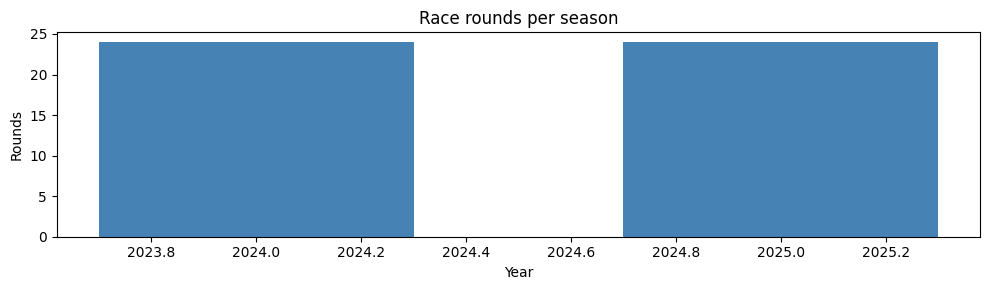

,year,n_rounds
0,2024,24
1,2025,24


In [52]:
coverage = (
    df.groupby('year')['round_number']
    .nunique()
    .rename('n_rounds')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(coverage['year'], coverage['n_rounds'], color='steelblue', width=0.6)
ax.set_xlabel('Year')
ax.set_ylabel('Rounds')
ax.set_title('Race rounds per season')
plt.tight_layout()
plt.show()

display(coverage)

## 4. Target variable — `RacePosition` distribution

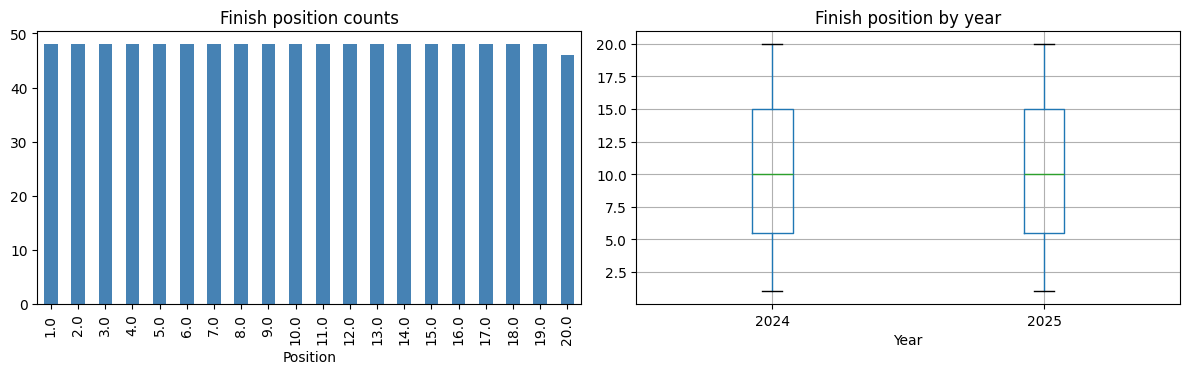

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['RacePosition'].value_counts().sort_index().plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('Finish position counts')
axes[0].set_xlabel('Position')

df.boxplot(column='RacePosition', by='year', ax=axes[1])
axes[1].set_title('Finish position by year')
axes[1].set_xlabel('Year')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 5. Univariate distributions — numeric features

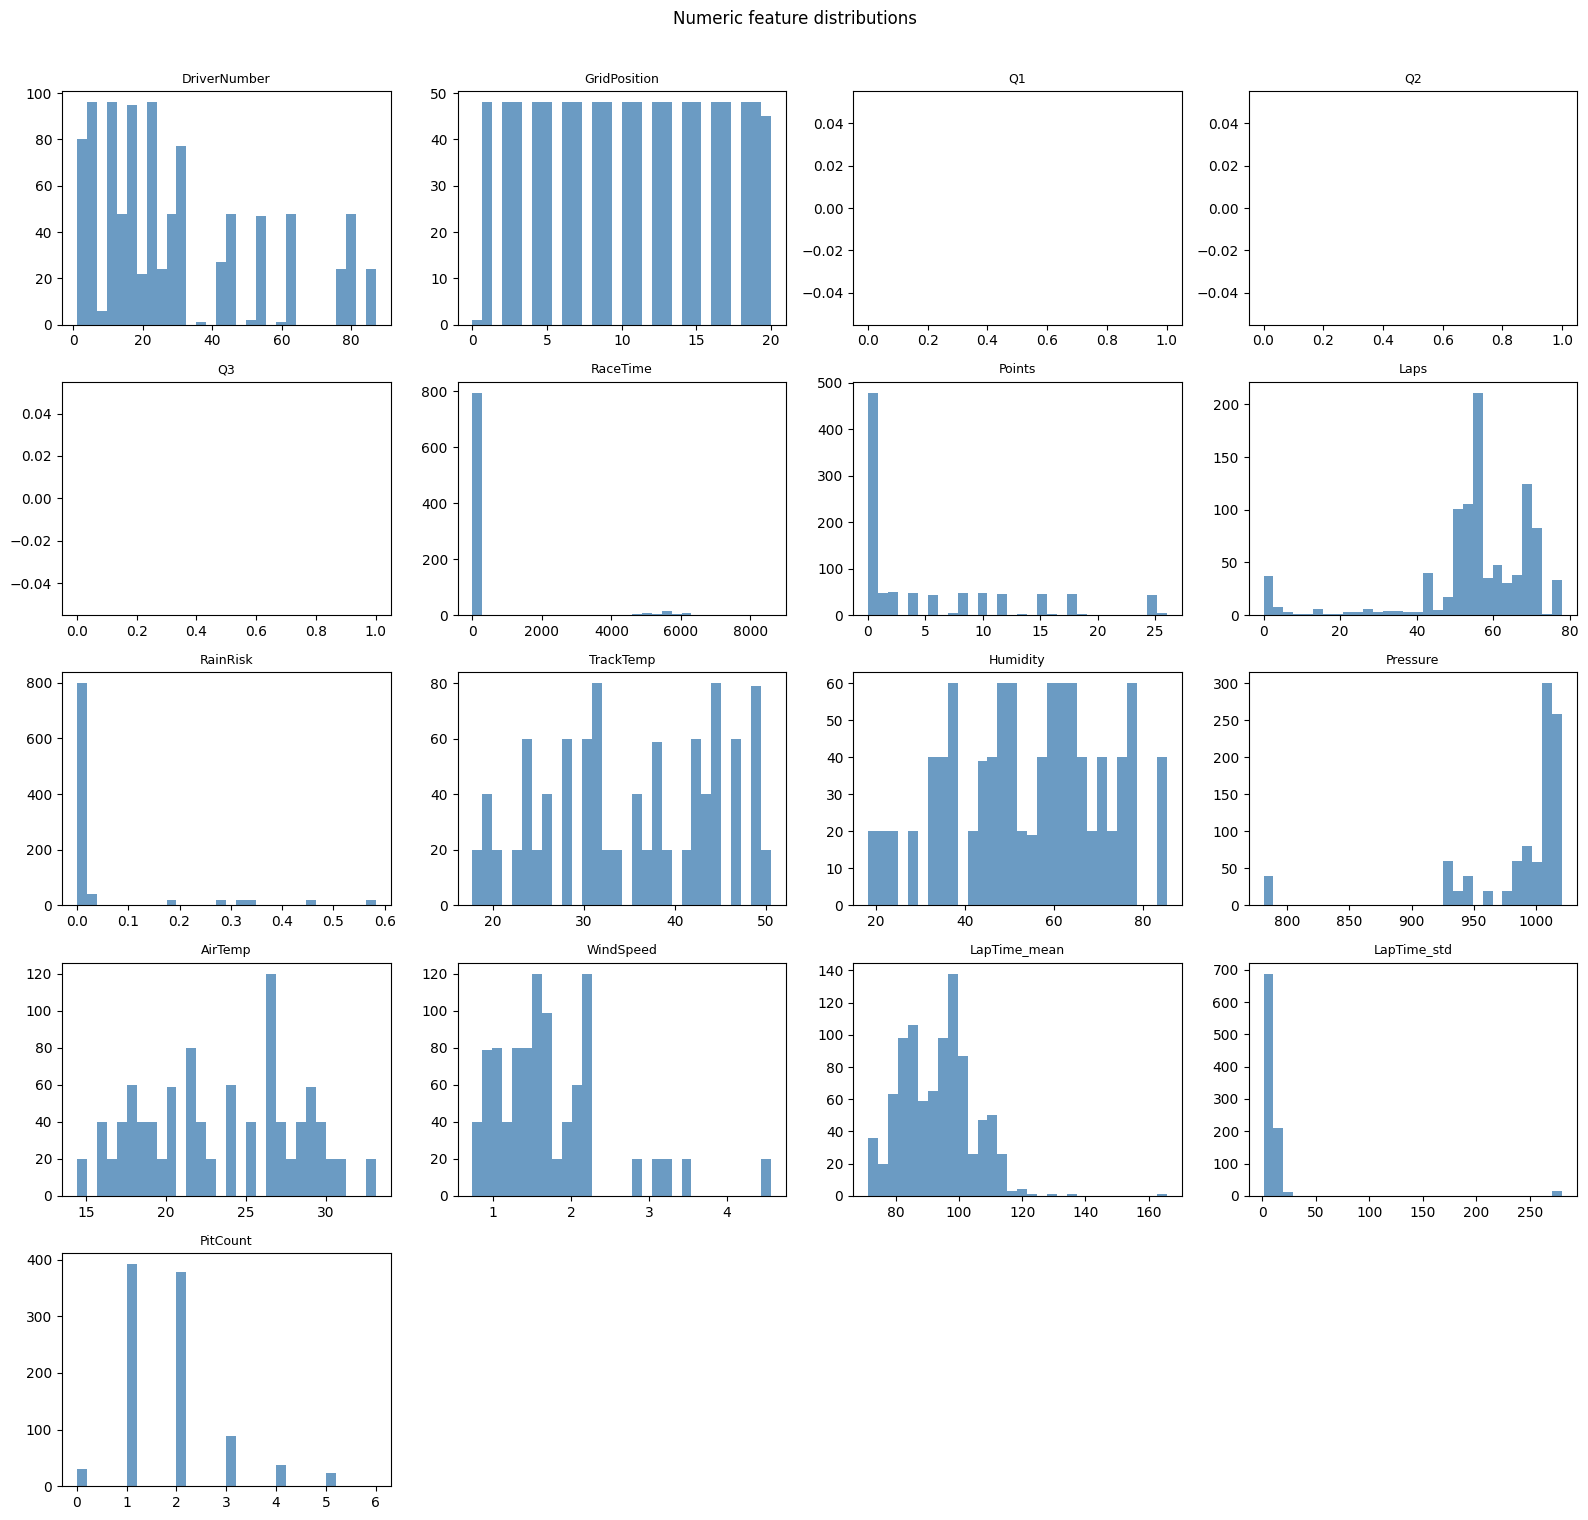

In [54]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['year', 'round_number', 'RacePosition']]

n     = len(numeric_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(col, fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric feature distributions', y=1.01)
plt.tight_layout()
plt.show()

## 6. Correlation with `RacePosition` (Spearman)

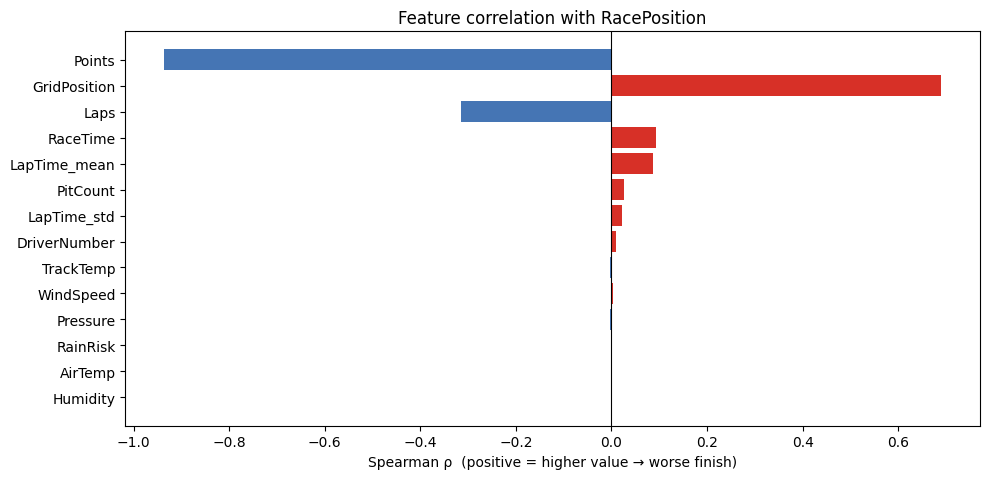

,feature,spearman_rho,p_value,abs_rho
3,Points,-0.936243,0.000000e+00,0.936243
1,GridPosition,0.690043,2.234911e-136,0.690043
4,Laps,-0.315751,1.275449e-23,0.315751
2,RaceTime,0.093367,6.672211e-03,0.093367
11,LapTime_mean,0.087601,7.517124e-03,0.087601
13,PitCount,0.025935,4.241133e-01,0.025935
12,LapTime_std,0.021719,5.091819e-01,0.021719
0,DriverNumber,0.009558,7.676466e-01,0.009558
6,TrackTemp,-0.002986,9.264702e-01,0.002986
10,WindSpeed,0.002364,9.417581e-01,0.002364


In [55]:
from scipy.stats import spearmanr

results = []
for col in numeric_cols:
    valid = df[[col, 'RacePosition']].dropna()
    if len(valid) < 30:
        continue
    rho, pval = spearmanr(valid[col], valid['RacePosition'])
    results.append({'feature': col, 'spearman_rho': rho, 'p_value': pval})

corr_df = (
    pd.DataFrame(results)
    .assign(abs_rho=lambda x: x['spearman_rho'].abs())
    .sort_values('abs_rho', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, max(4, len(corr_df) * 0.35)))
colors = ['#d73027' if r > 0 else '#4575b4' for r in corr_df['spearman_rho']]
ax.barh(corr_df['feature'], corr_df['spearman_rho'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Spearman ρ  (positive = higher value → worse finish)')
ax.set_title('Feature correlation with RacePosition')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(corr_df)

## 7. Feature × feature correlation heatmap
Flag pairs with |r| > 0.85 — likely multicollinear.

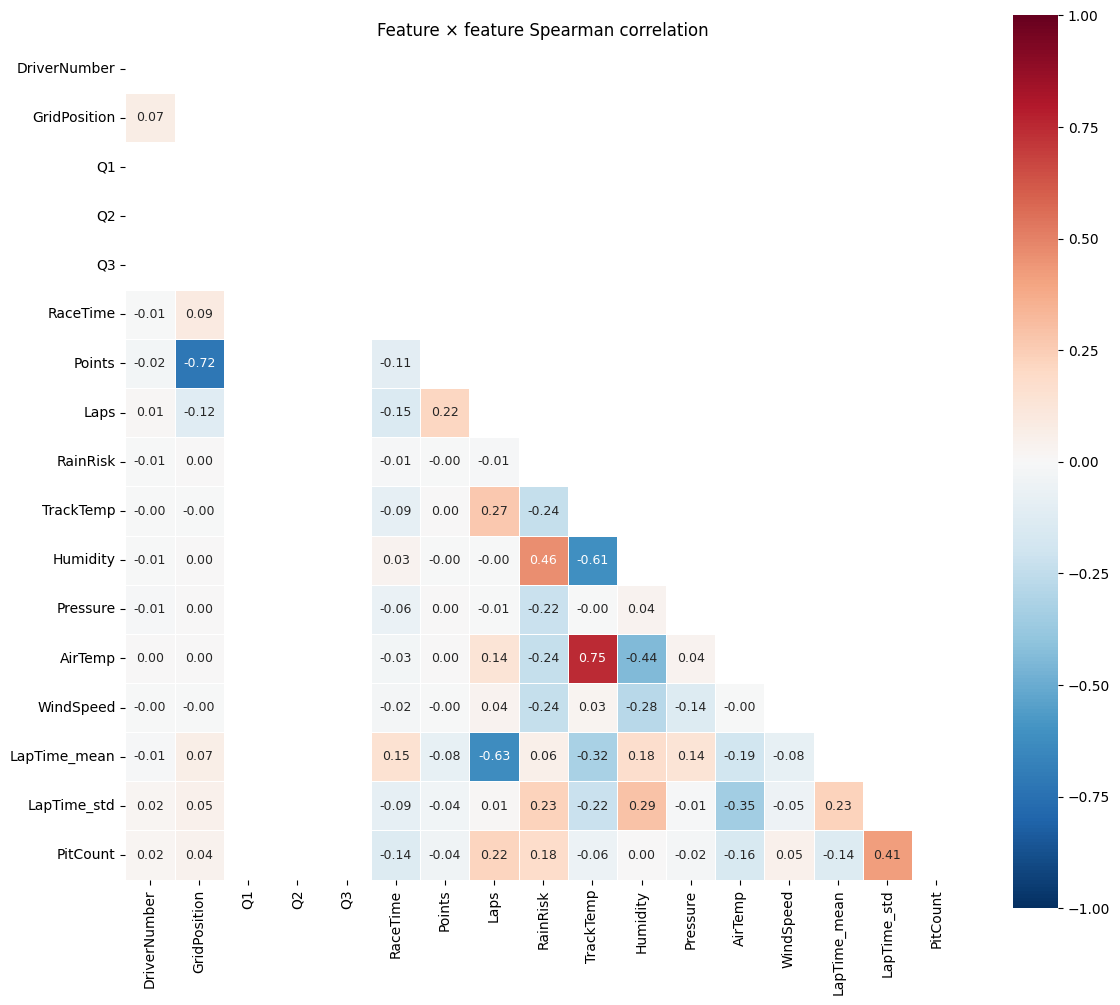

No pairs with |r| > 0.85 found.


In [56]:
feature_corr = df[numeric_cols].corr(method='spearman')
mask = np.triu(np.ones_like(feature_corr, dtype=bool))

fig, ax = plt.subplots(figsize=(max(8, len(numeric_cols) * 0.7),
                                max(6, len(numeric_cols) * 0.6)))
sns.heatmap(
    feature_corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.4, ax=ax, annot_kws={'size': 9}
)
ax.set_title('Feature × feature Spearman correlation')
plt.tight_layout()
plt.show()

high_corr = [
    (c1, c2, feature_corr.loc[c1, c2])
    for i, c1 in enumerate(feature_corr.columns)
    for c2 in feature_corr.columns[i+1:]
    if abs(feature_corr.loc[c1, c2]) > 0.85
]

if high_corr:
    print('Highly correlated pairs (|r| > 0.85):')
    for c1, c2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f'  {c1:35s}  {c2:35s}  r={r:.3f}')
else:
    print('No pairs with |r| > 0.85 found.')

## 8. Leakage registry

Every column in `df` must be classified before entering the model.

| Feature | Source | Available pre-race? | Keep / Drop | Notes |
|---|---|---|---|---|
| `GridPosition` | session_results | ✅ Yes | **Keep** | Qualifying determines grid |
| `RacePosition` | session_results | ❌ Target | **Target** | What we predict |
| `RaceTime` | session_results | ❌ Post-race | **Drop** | Known only after race ends |
| `ClassifiedPosition` | session_results | ❌ Post-race | **Drop** | |
| `Points` | session_results | ❌ Post-race | **Drop** | Derived from finish position |
| `Laps` | session_results | ❌ Post-race | **Drop** | |
| `Status` | session_results | ❌ Post-race | **Drop** | DNF/Finished etc. |
| `LapTime_mean` | laps_agg | ❌ Post-race | **Drop (use lag)** | Lag version is safe |
| `LapTime_std` | laps_agg | ❌ Post-race | **Drop (use lag)** | Lag version → `LapStd_lag1` |
| `PitCount` | laps_agg | ❌ Post-race | **Drop** | Strategy known only after race |
| `RainRisk` | weather | ⚠️ Caveat | **Keep w/ caveat** | Telemetry in train; forecast at inference |
| `TrackTemp` | weather | ⚠️ Caveat | **Keep w/ caveat** | Same caveat as RainRisk |
| `Humidity` | weather | ⚠️ Caveat | **Keep w/ caveat** | |
| `Pressure` | weather | ⚠️ Caveat | **Keep w/ caveat** | |
| `AirTemp` | weather | ⚠️ Caveat | **Keep w/ caveat** | |
| `WindSpeed` | weather | ⚠️ Caveat | **Keep w/ caveat** | |
| `DriverFinish_lag1` | engineered | ✅ Yes (lag) | **Keep** | Driver's finish in previous race |
| `DriverFinish_roll3` | engineered | ✅ Yes (lag) | **Keep** | Rolling mean over previous 3 races |
| `TeamFinish_roll3` | engineered | ✅ Yes (lag) | **Keep** | Team rolling mean |
| `LapStd_lag1` | engineered | ✅ Yes (lag) | **Keep** | Consistency proxy from previous race |

> **Weather caveat**: actual telemetry is used during training (no leakage — both target and features are post-race).  
> At inference, substitute with a weather forecast API.

## 9. Lag feature engineering

All lag/rolling features look **only backward** — `shift(1)` ensures no round-1 leakage across season boundaries.

In [57]:
df = df.sort_values(['DriverId', 'year', 'round_number']).reset_index(drop=True)

# ── Driver-level cross-season features ────────────────────────────────────────
# Sorted by DriverId → year → round_number, so shift(1) within DriverId group
# correctly references the previous race (may cross season boundary — intentional)

df['DriverFinish_lag1'] = (
    df.groupby('DriverId')['RacePosition'].shift(1)
)

df['DriverFinish_ewm'] = (
    df.groupby('DriverId')['RacePosition']
    .transform(lambda x: x.shift(1).ewm(span=5, min_periods=1).mean())
)

df['LapStd_lag1'] = (
    df.groupby('DriverId')['LapTime_std'].shift(1)
)

# ── Driver-level within-season features ───────────────────────────────────────
# Group by (DriverId, year) so the season resets at round 1 each year

df['DriverFinish_roll3_inseason'] = (
    df.groupby(['DriverId', 'year'])['RacePosition']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# ── Team-level features — pre-aggregate to team-race level first ───────────────
# Grouping directly by (TeamName, year) on a driver-sorted frame would leak
# Driver A's last race into Driver B's round 1 via shift(1). Fix: average both
# drivers to one team-race row, roll that, then join back.

team_race = (
    df.groupby(['TeamName', 'year', 'round_number'])['RacePosition']
    .mean()
    .reset_index(name='TeamAvgPosition')
    .sort_values(['TeamName', 'year', 'round_number'])
)

team_race['TeamFinish_ewm'] = (
    team_race.groupby('TeamName')['TeamAvgPosition']
    .transform(lambda x: x.shift(1).ewm(span=5, min_periods=1).mean())
)

team_race['TeamFinish_roll3_inseason'] = (
    team_race.groupby(['TeamName', 'year'])['TeamAvgPosition']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

df = df.merge(
    team_race[['TeamName', 'year', 'round_number', 'TeamFinish_ewm', 'TeamFinish_roll3_inseason']],
    on=['TeamName', 'year', 'round_number'],
    how='left'
)

# ── Sanity checks ──────────────────────────────────────────────────────────────
round1 = df[df['round_number'] == 1]
assert round1['DriverFinish_roll3_inseason'].isna().all(), 'Season boundary leak in DriverFinish_roll3_inseason!'
assert round1['TeamFinish_roll3_inseason'].isna().all(),   'Season boundary leak in TeamFinish_roll3_inseason!'

print('Features added successfully.')
df[['year', 'round_number', 'DriverId', 'RacePosition',
    'DriverFinish_lag1', 'DriverFinish_roll3_inseason', 'DriverFinish_ewm',
    'TeamFinish_roll3_inseason', 'TeamFinish_ewm']].head(20)

Features added successfully.


,year,round_number,DriverId,RacePosition,DriverFinish_lag1,DriverFinish_roll3_inseason,DriverFinish_ewm,TeamFinish_roll3_inseason,TeamFinish_ewm
0,2024,1,albon,15.0,<NA>,NaN,NaN,NaN,NaN
1,2024,2,albon,11.0,15.0,15.000000,15.000000,17.500000,17.500000
2,2024,3,albon,11.0,11.0,13.000000,12.600000,15.000000,14.500000
3,2024,4,albon,20.0,11.0,12.333333,11.842105,13.666667,12.842105
4,2024,5,albon,12.0,20.0,14.000000,15.230769,14.000000,15.192308
5,2024,6,albon,18.0,12.0,14.333333,13.990521,14.666667,14.926540
6,2024,7,albon,20.0,18.0,16.666667,15.455639,17.333333,16.415038
7,2024,8,albon,9.0,20.0,16.666667,17.064594,17.333333,17.153230
8,2024,9,albon,17.0,9.0,15.666667,14.267248,16.500000,15.365741
9,2024,10,albon,18.0,17.0,15.333333,15.202493,16.333333,16.438397


## 9a. Correlation — all engineered features vs `RacePosition`

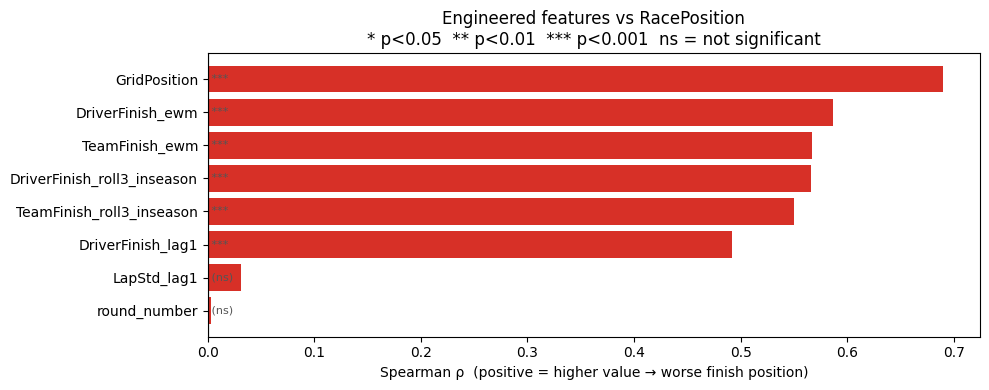

,feature,spearman_rho,p_value,n
0,GridPosition,0.6900,0.0000,958
3,DriverFinish_ewm,0.5865,0.0000,931
5,TeamFinish_ewm,0.5668,0.0000,938
4,DriverFinish_roll3_inseason,0.5656,0.0000,913
6,TeamFinish_roll3_inseason,0.5497,0.0000,918
2,DriverFinish_lag1,0.4916,0.0000,931
7,LapStd_lag1,0.0310,0.3527,901
1,round_number,0.0032,0.9203,958


In [58]:
from scipy.stats import spearmanr

ENGINEERED_FEATURES = [
    'GridPosition',
    'round_number',
    'DriverFinish_lag1',
    'DriverFinish_ewm',
    'DriverFinish_roll3_inseason',
    'TeamFinish_ewm',
    'TeamFinish_roll3_inseason',
    'LapStd_lag1',
]

rows = []
for col in ENGINEERED_FEATURES:
    if col not in df.columns:
        continue
    valid = df[[col, 'RacePosition']].dropna()
    if len(valid) < 30:
        rows.append({'feature': col, 'spearman_rho': np.nan, 'p_value': np.nan, 'n': len(valid)})
        continue
    rho, pval = spearmanr(valid[col], valid['RacePosition'])
    rows.append({'feature': col, 'spearman_rho': rho, 'p_value': pval, 'n': len(valid)})

eng_corr = (
    pd.DataFrame(rows)
    .assign(abs_rho=lambda x: x['spearman_rho'].abs())
    .sort_values('abs_rho', ascending=False)
)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, max(4, len(eng_corr) * 0.45)))

colors = [
    '#d73027' if r > 0 else '#4575b4'
    for r in eng_corr['spearman_rho'].fillna(0)
]
bars = ax.barh(eng_corr['feature'], eng_corr['spearman_rho'], color=colors, edgecolor='none')

# Significance markers
for i, (_, row) in enumerate(eng_corr.iterrows()):
    if pd.isna(row['p_value']):
        marker = '  (n too small)'
    elif row['p_value'] < 0.001:
        marker = ' ***'
    elif row['p_value'] < 0.01:
        marker = ' **'
    elif row['p_value'] < 0.05:
        marker = ' *'
    else:
        marker = ' (ns)'
    ax.text(0, i, marker, va='center', fontsize=8, color='#555')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Spearman ρ  (positive = higher value → worse finish position)')
ax.set_title('Engineered features vs RacePosition\n* p<0.05  ** p<0.01  *** p<0.001  ns = not significant')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(eng_corr[['feature', 'spearman_rho', 'p_value', 'n']].round(4))

## 10. Train / test split — season boundary

Split on year to prevent future-race data leaking into training.

In [59]:
TEST_YEARS = [2025]

train = df[~df['year'].isin(TEST_YEARS)].copy()
test  = df[ df['year'].isin(TEST_YEARS)].copy()

print(f'Train: {len(train):,} rows  |  years: {sorted(train["year"].unique())}')
print(f'Test:  {len(test):,} rows   |  years: {sorted(test["year"].unique())}')

overlap = set(train['year']) & set(test['year'])
assert not overlap, f'Year overlap: {overlap}'
print('Split OK — no year overlap.')

Train: 479 rows  |  years: [np.int32(2024)]
Test:  479 rows   |  years: [np.int32(2025)]
Split OK — no year overlap.


## 11. Locked feature list

`FINAL_FEATURES` is the single source of truth — import this into the modelling notebook.

In [60]:
FINAL_FEATURES = [
    # Pre-race, always known
    'GridPosition',
    'round_number',             # season context — model learns opener uncertainty
    # Categorical (encode before modelling)
    'TeamName',
    'Meeting.Circuit.ShortName',
    # Cross-season rolling — available even at race 1, decays older data
    'DriverFinish_lag1',
    'DriverFinish_ewm',
    'TeamFinish_ewm',
    # Within-season rolling — NaN until race 2, reliable from race 4 onwards
    'DriverFinish_roll3_inseason',
    'TeamFinish_roll3_inseason',
    # Consistency proxy from previous race (lap time std, lagged)
    'LapStd_lag1',
]

TARGET = 'RacePosition'

X_train = train[FINAL_FEATURES]
y_train = train[TARGET]
X_test  = test[FINAL_FEATURES]
y_test  = test[TARGET]

print(f'Feature count : {len(FINAL_FEATURES)}')
print(f'X_train shape : {X_train.shape}')
print(f'X_test  shape : {X_test.shape}')
print('\nNull counts in X_train:')
print(X_train.isnull().sum().to_string())
print('\nNull counts in X_test:')
print(X_test.isnull().sum().to_string())

Feature count : 10
X_train shape : (479, 10)
X_test  shape : (479, 10)

Null counts in X_train:
GridPosition                    0
round_number                    0
TeamName                        0
Meeting.Circuit.ShortName       0
DriverFinish_lag1              24
DriverFinish_ewm               24
TeamFinish_ewm                 20
DriverFinish_roll3_inseason    24
TeamFinish_roll3_inseason      20
LapStd_lag1                    38

Null counts in X_test:
GridPosition                    0
round_number                    0
TeamName                        0
Meeting.Circuit.ShortName       0
DriverFinish_lag1               3
DriverFinish_ewm                3
TeamFinish_ewm                  0
DriverFinish_roll3_inseason    21
TeamFinish_roll3_inseason      20
LapStd_lag1                    19


## Tuning note — EWMA span and rolling window

Four feature engineering choices were not validated against held-out data — treat all as hyperparameters to tune during modelling.

**EWMA `span` (currently `5`, α ≈ 0.333)**
Affects: `DriverFinish_ewm`, `TeamFinish_ewm`
Candidates: `span ∈ {3, 5, 8, 10}`. Smaller spans react faster to recent form; larger spans smooth over variance at the cost of slower adaptation.

**Rolling `window` (currently `3`)**
Affects: `DriverFinish_roll3_inseason`, `TeamFinish_roll3_inseason`
Candidates: `window ∈ {3, 5, 7}`. Note: larger windows increase the NaN rate in early-season rows (rounds 1 through window − 1), so check null counts after changing this value.